In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
data = pd.read_csv('train.csv')

In [16]:
data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [17]:
data['Family_Size'].max()

np.float64(9.0)

In [18]:
data['Profession'].unique()

<ArrowStringArray>
[   'Healthcare',      'Engineer',        'Lawyer', 'Entertainment',
        'Artist',     'Executive',        'Doctor',     'Homemaker',
     'Marketing',             nan]
Length: 10, dtype: str

In [19]:
data = data.reset_index(drop=True)
data = data.drop(columns=['ID'])


In [20]:
data = data.rename(columns={'Var_1':'Category'})

In [21]:
data.shape

(8068, 10)

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   str    
 1   Ever_Married     7928 non-null   str    
 2   Age              8068 non-null   int64  
 3   Graduated        7990 non-null   str    
 4   Profession       7944 non-null   str    
 5   Work_Experience  7239 non-null   float64
 6   Spending_Score   8068 non-null   str    
 7   Family_Size      7733 non-null   float64
 8   Category         7992 non-null   str    
 9   Segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 855.9 KB


In [23]:
data['Profession'].value_counts()

Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

<Axes: xlabel='Ever_Married', ylabel='count'>

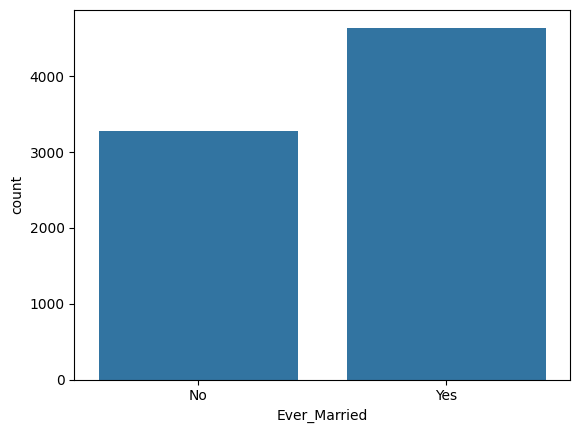

In [24]:
sns.countplot(x='Ever_Married',data=data)

<Axes: xlabel='Family_Size', ylabel='count'>

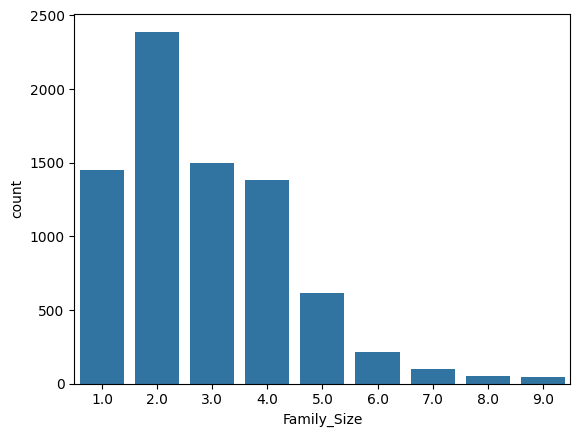

In [25]:
sns.countplot(x='Family_Size',data=data)

In [26]:
data['Work_Experience'].value_counts()

Work_Experience
1.0     2354
0.0     2318
9.0      474
8.0      463
2.0      286
3.0      255
4.0      253
6.0      204
7.0      196
5.0      194
10.0      53
11.0      50
12.0      48
13.0      46
14.0      45
Name: count, dtype: int64

<Axes: xlabel='Graduated', ylabel='count'>

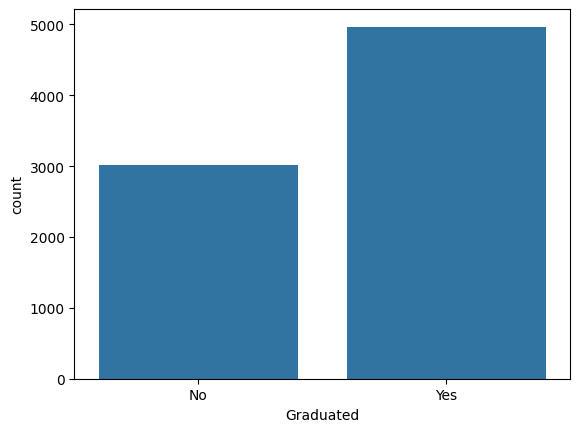

In [27]:
sns.countplot(x='Graduated',data=data)

In [28]:
data['Category'].value_counts()

Category
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
Name: count, dtype: int64

In [29]:
data['Ever_Married'] = data['Ever_Married'].fillna('Yes')
data['Graduated'] = data['Graduated'].fillna('Yes')
data['Profession'] = data['Profession'].fillna('Artist')
data['Work_Experience'] = data['Work_Experience'].fillna(1)
data['Family_Size'] = data['Family_Size'].fillna(2)
data['Category'] = data['Category'].fillna('Cat_6')


<Axes: xlabel='Spending_Score', ylabel='count'>

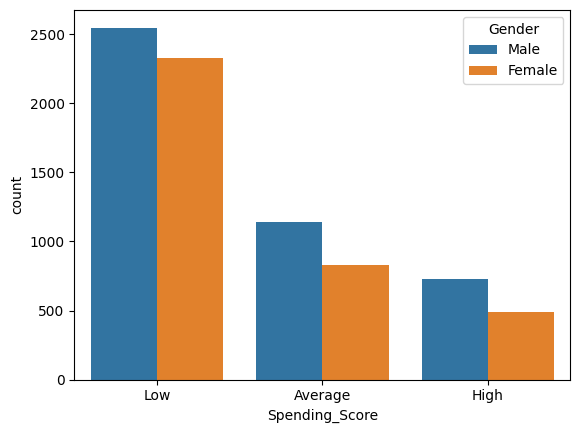

In [30]:
sns.countplot(x='Spending_Score',hue='Gender',data=data)

In [31]:
data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Category,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,A


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   str    
 1   Ever_Married     8068 non-null   str    
 2   Age              8068 non-null   int64  
 3   Graduated        8068 non-null   str    
 4   Profession       8068 non-null   str    
 5   Work_Experience  8068 non-null   float64
 6   Spending_Score   8068 non-null   str    
 7   Family_Size      8068 non-null   float64
 8   Category         8068 non-null   str    
 9   Segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 853.7 KB


In [33]:
data['Segmentation'].describe()

count     8068
unique       4
top          D
freq      2268
Name: Segmentation, dtype: object

<Axes: xlabel='count', ylabel='Segmentation'>

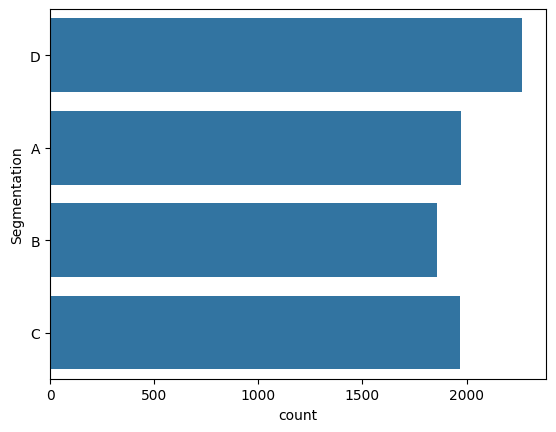

In [34]:
sns.countplot(data['Segmentation'])

In [35]:
data.groupby('Segmentation').agg({'Age':'mean','Work_Experience':'mean','Family_Size':'mean'})

,Age,Work_Experience,Family_Size
Segmentation,,,
A,44.924949,2.690162,2.418357
B,48.200215,2.235737,2.680840
C,49.144162,2.143147,2.952792
D,33.390212,2.764991,3.149471


In [36]:
# 'Category':'count','Spending_Score':'count'
data.groupby('Spending_Score').agg({'Age':'mean','Work_Experience':'mean','Family_Size':'mean', 'Segmentation':'count'})

,Age,Work_Experience,Family_Size,Segmentation
Spending_Score,,,,
Average,46.868288,2.357649,3.087639,1974
High,57.777138,1.970395,2.967105,1216
Low,38.523165,2.644936,2.666462,4878


In [37]:
data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Category,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,A


<Axes: xlabel='Segmentation', ylabel='count'>

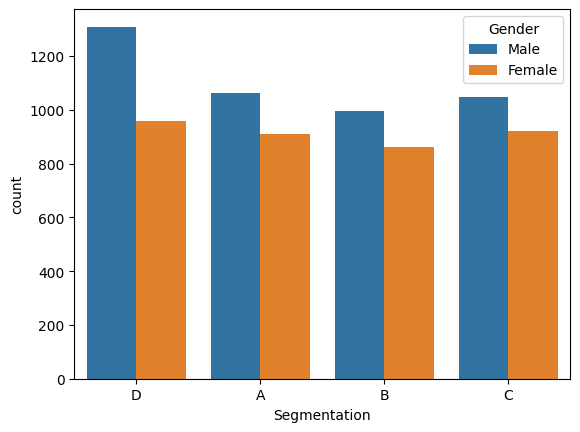

In [38]:
sns.countplot(x='Segmentation',hue='Gender',data=data)

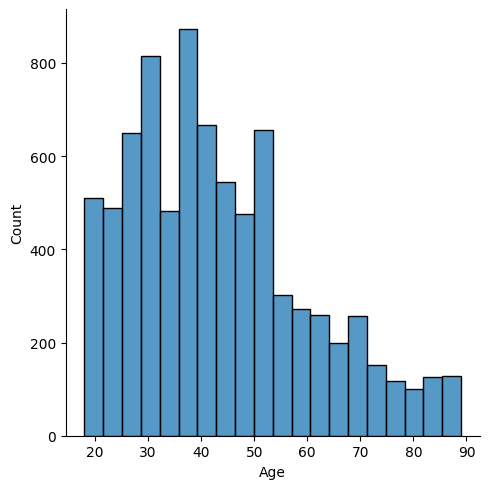

In [39]:
sns.displot(data['Age'],bins=20)

<Axes: xlabel='Segmentation', ylabel='count'>

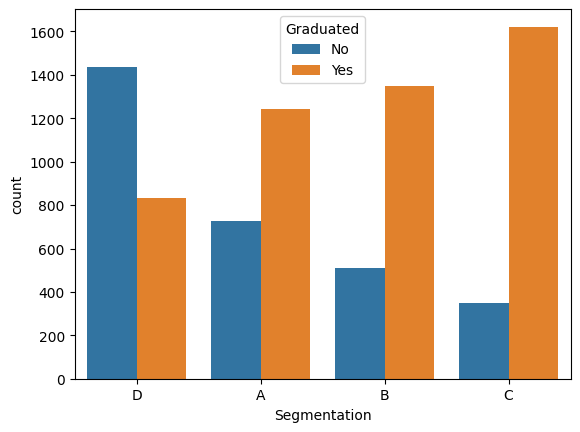

In [40]:
sns.countplot(x='Segmentation',hue='Graduated',data=data)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Healthcare'),
  Text(1, 0, 'Engineer'),
  Text(2, 0, 'Lawyer'),
  Text(3, 0, 'Entertainment'),
  Text(4, 0, 'Artist'),
  Text(5, 0, 'Executive'),
  Text(6, 0, 'Doctor'),
  Text(7, 0, 'Homemaker'),
  Text(8, 0, 'Marketing')])

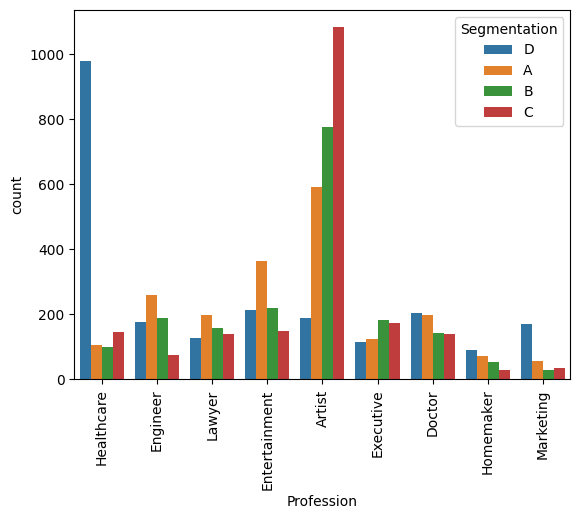

In [41]:
sns.countplot(x='Profession',hue='Segmentation',data=data)
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'D'), Text(1, 0, 'A'), Text(2, 0, 'B'), Text(3, 0, 'C')])

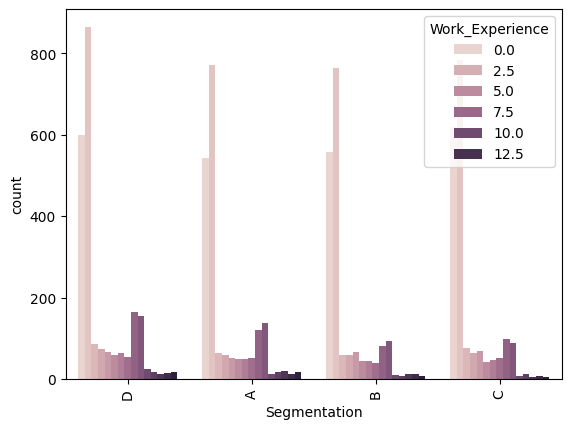

In [42]:
sns.countplot(x='Segmentation',hue='Work_Experience',data=data)
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'D'), Text(1, 0, 'A'), Text(2, 0, 'B'), Text(3, 0, 'C')])

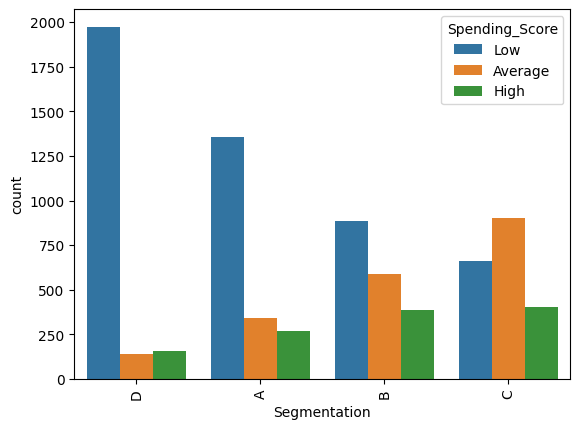

In [43]:
sns.countplot(x='Segmentation',hue='Spending_Score',data=data)
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'D'), Text(1, 0, 'A'), Text(2, 0, 'B'), Text(3, 0, 'C')])

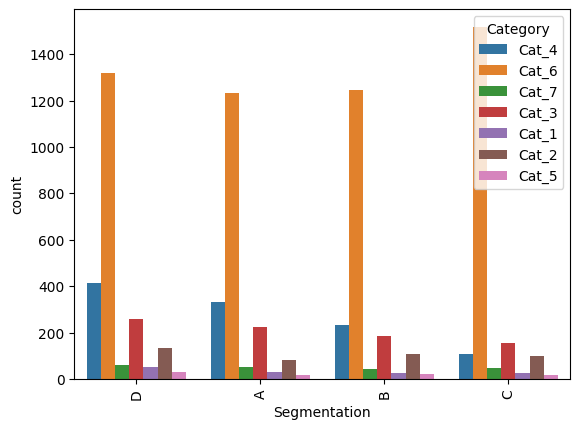

In [44]:
sns.countplot(x='Segmentation',hue='Category',data=data)
plt.xticks(rotation=90)

In [45]:
data['Segmentation'] = data['Segmentation'].replace({'A':1,'B':2,'C':3,'D':4}).astype(int)

In [46]:
data['Profession'].unique()

<ArrowStringArray>
[   'Healthcare',      'Engineer',        'Lawyer', 'Entertainment',
        'Artist',     'Executive',        'Doctor',     'Homemaker',
     'Marketing']
Length: 9, dtype: str

In [47]:
data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Category,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,4
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,1
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,2
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,2
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,1


In [48]:
corr_data = data.select_dtypes(include=['number']).corr()

<Axes: >

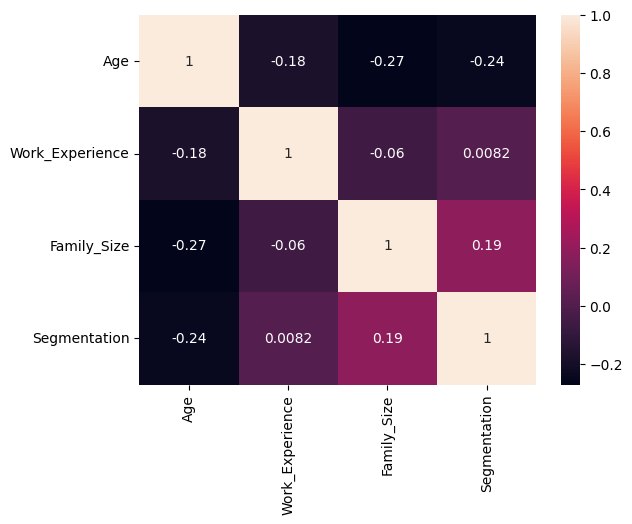

In [49]:
sns.heatmap(corr_data,annot=True)

In [50]:
data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Category,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,4
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,1
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,2
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,2
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,1


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['Segmentation']), data['Segmentation'], test_size=0.2, stratify=data['Segmentation'])

In [52]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[['Low','Average','High']]), ['Spending_Score']),
        
        ('nom', OneHotEncoder(sparse_output=False, handle_unknown='ignore',drop='first'), ['Gender','Ever_Married','Graduated','Profession','Category']),
    ]
)

In [54]:
X_train_temp = preprocessor.fit_transform(X_train)

In [55]:
scaler = StandardScaler()

In [56]:
my_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('num', scaler)
    ]
)

In [57]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 6454 entries, 4080 to 129
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           6454 non-null   str    
 1   Ever_Married     6454 non-null   str    
 2   Age              6454 non-null   int64  
 3   Graduated        6454 non-null   str    
 4   Profession       6454 non-null   str    
 5   Work_Experience  6454 non-null   float64
 6   Spending_Score   6454 non-null   str    
 7   Family_Size      6454 non-null   float64
 8   Category         6454 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 681.1 KB


In [58]:
X_train = my_pipeline.fit_transform(X_train)
X_test = my_pipeline.transform(X_test)

In [59]:
from sklearn.neighbors import KNeighborsClassifier

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(3, 31, 2)),   # odd values, 3 to 29
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [61]:
print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)


Best params: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}
Best CV accuracy: 0.48760506548015775


In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.36      0.42      0.39       394
           2       0.35      0.26      0.30       372
           3       0.56      0.54      0.55       394
           4       0.59      0.65      0.62       454

    accuracy                           0.48      1614
   macro avg       0.47      0.47      0.46      1614
weighted avg       0.47      0.48      0.47      1614



In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.38      0.33      0.35       394
           2       0.32      0.28      0.30       372
           3       0.53      0.56      0.54       394
           4       0.59      0.68      0.63       454

    accuracy                           0.47      1614
   macro avg       0.45      0.46      0.46      1614
weighted avg       0.46      0.47      0.46      1614



In [64]:
import pandas as pd

feature_names = my_pipeline.named_steps['preprocessing'].get_feature_names_out()
importances = pd.Series(rf_classifier.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(10)

ord__Spending_Score              0.174226
nom__Profession_Healthcare       0.160083
nom__Graduated_Yes               0.136086
nom__Ever_Married_Yes            0.096617
nom__Gender_Male                 0.072353
nom__Profession_Entertainment    0.039777
nom__Profession_Engineer         0.034443
nom__Category_Cat_4              0.033838
nom__Profession_Marketing        0.033135
nom__Category_Cat_6              0.032981
dtype: float64

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best params:", grid_search_rf.best_params_)
print("Best CV accuracy:", grid_search_rf.best_score_)

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV accuracy: 0.5063526261116016
              precision    recall  f1-score   support

           1       0.39      0.47      0.43       394
           2       0.37      0.27      0.31       372
           3       0.57      0.55      0.56       394
           4       0.62      0.67      0.64       454

    accuracy                           0.50      1614
   macro avg       0.49      0.49      0.48      1614
weighted avg       0.49      0.50      0.49      1614



In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

In [67]:
cm

array([[184,  74,  51,  85],
       [113, 100, 106,  53],
       [ 57,  68, 217,  52],
       [112,  29,   9, 304]])

In [68]:
import joblib

In [69]:
joblib.dump(best_rf, 'customer_segmentation_rf.pkl')
joblib.dump(my_pipeline, 'customer_segmentation_pipeline.pkl')

['customer_segmentation_pipeline.pkl']

In [70]:
import pandas as pd

In [71]:
new_data = pd.read_csv('test.csv')

In [72]:
new_data = new_data.reset_index(drop=True)
new_data = new_data.drop(columns=['ID'])
new_data = new_data.rename(columns={'Var_1':'Category'})


new_data['Ever_Married'] = new_data['Ever_Married'].fillna('Yes')
new_data['Graduated'] = new_data['Graduated'].fillna('Yes')
new_data['Profession'] = new_data['Profession'].fillna('Artist')
new_data['Work_Experience'] = new_data['Work_Experience'].fillna(1)
new_data['Family_Size'] = new_data['Family_Size'].fillna(2)
new_data['Category'] = new_data['Category'].fillna('Cat_6')


In [73]:
model = joblib.load('customer_segmentation_rf.pkl')
pipeline = joblib.load('customer_segmentation_pipeline.pkl')

X_new = pipeline.transform(new_data)
predictions = model.predict(X_new)

In [74]:
predictions

array([2, 4, 1, ..., 1, 2, 4], shape=(2627,))